In [87]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
from sklearn.svm import SVC, LinearSVC
import re 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

import warnings

from sklearn import set_config
set_config(display='diagram')

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")   

In [88]:
df = pd.read_csv("winter_project_2026/development.csv")

category_map = {
    0: "International News",
    1: "Business",
    2: "Technology",
    3: "Entertainment",
    4: "Sports",
    5: "General News",
    6: "Health"
}

df.dropna(inplace=True)
print(df.dtypes)
print(df.shape)


Id            int64
source       object
title        object
article      object
page_rank     int64
timestamp    object
label         int64
dtype: object
(79995, 7)


# RIMOZIONE RUMORI


In [ ]:
remove_short = True
remove_duplicates2 = True


if remove_duplicates2:
    len_prima = df.shape[0]
    df = df.drop_duplicates(subset=['article'], keep='first').reset_index(drop=True)
    len_dopo = df.shape[0]
    print(f"dup -> {len_prima - len_dopo} extra copies removed (1 copy kept)")



if remove_short:
    mask_len = df['article'].str.len() >= 50
    df = df[mask_len].copy() 
    print(f"too short -> {(~mask_len).sum()} has been removed")

    df = df.reset_index(drop=True)


df = df.reset_index(drop = True)


dup -> 5602 extra copies removed (1 copy kept)
too short -> 707 has been removed


In [ ]:
def clean_text_without_url(text):
    if not isinstance(text, str):
        return ""

    # capturing alt captions from HTML before stripping tags
    captions = " ".join(re.findall(r'alt="([^"]*)"', text))
    captions = re.sub(r'[^a-zA-Z\s]', ' ', captions)

    # removing the URL messages 
    text_no_links = re.sub(r'https?://\S+', ' ', text)

    # remove HTML tags
    text_without_tags = re.sub(r'<[^>]+>', ' ', text_no_links)

    # keep information about money simbols
    text_without_tags = re.sub(
        r'[$€£¥]',
        ' MONEYAMOUNT ',
        text_without_tags
    )

    # this removes punctuation, numbers
    text_final = re.sub(r"[^a-zA-Z\s]", ' ', text_without_tags)

    combined = text_final  + " " + captions

    # 6. lower casse and extra whitespace removal
    return re.sub(r'\s+', ' ', combined).strip().lower()

clean_text = clean_text_without_url

# DEFINIZIONE DEI CLEANER E TRASFORMATORI

In [ ]:
def cleaner_applyer(df):
    df['title'] = df['title'].fillna('').apply(clean_text)
    df['article'] = df['article'].fillna('').apply(clean_text)
    df['source'] = df['source'].fillna('')
    df['combined_text'] = df['title'] + " " + df['article']
    df['combined_text2'] = df['title'] + " " + df['article']



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer 
from nltk.tokenize import word_tokenize 
from nltk.stem.wordnet import WordNetLemmatizer 
from nltk.corpus import stopwords as sw 
import nltk



class LemmaTokenizerGood(object): 
    def __init__(self): 
        self.lemmatizer = WordNetLemmatizer() 
        self.stop_words = set(sw.words('english'))
    
    def __call__(self, document): 
        lemmas = [] 
        for t in word_tokenize(document): 
            t = t.lower().strip()
            
            # if t still contains some other character differente from letters, or it is the stopword set, or it is too shot, it is removed
            if t.isalpha() and t not in self.stop_words and len(t) > 2:
                # lemmatizing to extract its root form
                lemma = self.lemmatizer.lemmatize(t) 
                lemmas.append(lemma)
                
        return lemmas
    

lemmaTokenizer = LemmaTokenizerGood()   
text_transformer1 = TfidfVectorizer(
    max_features=250000, 
    tokenizer=lemmaTokenizer, 
    stop_words=None, 
    ngram_range=(1, 2), 
    sublinear_tf=True, 
    norm='l2', 
    use_idf = True,
    min_df=3, 
    max_df=0.1)  

In [93]:
from sklearn.base import BaseEstimator, TransformerMixin

class TextCleanerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self  # Non deve fare nulla in fase di fit
    
    def transform(self, X):
        # create a copy
        X = X.copy()
            
        cleaner_applier(X)
        
        return X

In [94]:
source_transformer = OneHotEncoder(handle_unknown='ignore')
text_transformer_classic_char = TfidfVectorizer(analyzer='char',
    ngram_range=(3, 5),
    min_df=5,
    max_df=0.5,
    max_features=120_000,
    sublinear_tf=True,
    norm='l2',
    use_idf=True)

# PIPELINE SVC

In [ ]:

num_transformer = StandardScaler()

preprocessor_svc = ColumnTransformer(
    transformers=[
        ('text', text_transformer1, 'combined_text'),
        ('char', text_transformer_classic_char, 'combined_text2'), 
        ('source', source_transformer, ['source']),
        ('pagerank', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', MinMaxScaler())
        ]), ['page_rank']),
        ('year', OneHotEncoder(handle_unknown='ignore'), ['year']),
        ('lenght', MinMaxScaler(), ['article_len'])
        
    ], remainder='drop'
)

best_pipeline_params_svc = { 
    'preprocessor__text__sublinear_tf' : True,
'preprocessor__text__ngram_range' : (1, 3),
'preprocessor__text__min_df' : 5,
'preprocessor__text__max_features' : 200_000,
'preprocessor__text__max_df' : 0.15,
'preprocessor__text__use_idf' : True,
# 'preprocessor_pipeline__preprocessor__text__smooth_idf' : True,
'preprocessor__text__binary': False,
'preprocessor__text__norm' : 'l2',


'clf__C' : 0.075,
'clf__class_weight' : 'balanced', # or balanced or None
# 'preprocessor_pipeline__selector__k' : 'all',  # 'all' if i want all feauture

# char preprocessor

'preprocessor__char__sublinear_tf' : True,
'preprocessor__char__ngram_range' : (3, 5),
'preprocessor__char__min_df' : 5,
'preprocessor__char__max_features' : 120_000,
'preprocessor__char__max_df' : 0.06,
'preprocessor__char__use_idf' : True,
'preprocessor__char__norm' : 'l2',

}

linear_svc = LinearSVC()

pipe_svc = Pipeline([
    ('preprocessor', preprocessor_svc),
    ("clf", linear_svc)
])


pipe_svc = pipe_svc.set_params(**best_pipeline_params_svc)

pipe_svc

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('char', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# PIPELINE BAYESIAN

In [ ]:

preprocessor_mnb = ColumnTransformer(
    transformers=[
        ('text', text_transformer1, 'combined_text'),
        # ('char', text_transformer_classic_char, 'combined_text2'), 
        ('source', source_transformer, ['source']),
        ('pagerank', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', MinMaxScaler())
        ]), ['page_rank']),
        ('year', OneHotEncoder(handle_unknown='ignore'), ['year']),
        ('lenght', MinMaxScaler(), ['article_len'])
        
    ], remainder='drop'
)

best_pipeline_params_mnb = { 
'preprocessor__text__sublinear_tf' : True,
'preprocessor__text__ngram_range' : (1, 2),
'preprocessor__text__min_df' : 10,
'preprocessor__text__max_features' : 200000,
'preprocessor__text__max_df' : 0.12,
'preprocessor__text__use_idf' : True,
'preprocessor__text__smooth_idf' : True,
'clf__alpha' : 0.5,
'clf__fit_prior' : False,
'preprocessor__text__binary': False,
# 'preprocessor_pipeline__selector__k' : 50000 ,      

# char preprocessor

# 'preprocessor__char__sublinear_tf' : True,
# 'preprocessor__char__ngram_range' : (3, 5),
# 'preprocessor__char__min_df' : 5,
# 'preprocessor__char__max_features' : 0,
# 'preprocessor__char__max_df' : 0.2,
# 'preprocessor__char__use_idf' : True,
# 'preprocessor__char__smooth_idf' : True,
# 'preprocessor__char__norm' : 'l2',
}

from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
pipe_mnb = Pipeline([
    ('preprocessor', preprocessor_mnb),
    ("clf", mnb)
])

pipe_mnb = pipe_mnb.set_params(**best_pipeline_params_mnb)

pipe_mnb


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('source', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# CREAZIONE X E Y

In [97]:
cleaner = TextCleanerTransformer()
df = cleaner.fit_transform(df)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['year'] = df['timestamp'].dt.year
df['year'] = df['year'].fillna(0)
df['article_len'] = df['article'].fillna('').str.len()
X = df.drop(columns=['label'])
y = df['label']



df.isna().sum().sum()

np.int64(25350)


🔹 Testing max_features = 1000

🔹 Testing max_features = 5000

🔹 Testing max_features = 10000

🔹 Testing max_features = 25000

🔹 Testing max_features = 50000

🔹 Testing max_features = 100000

🔹 Testing max_features = 200000

🔹 Testing max_features = 300000


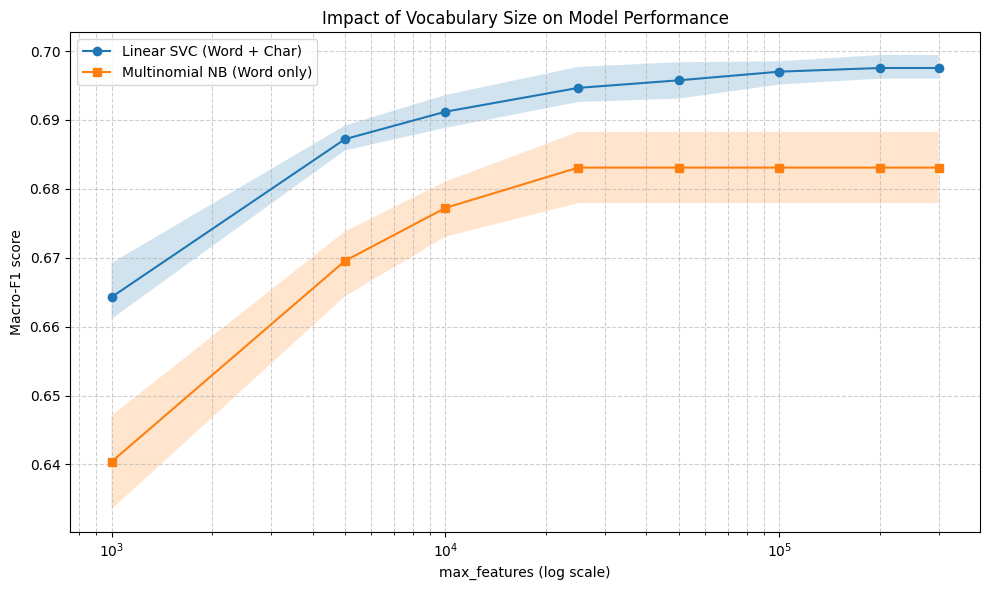

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from copy import deepcopy


n_values = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000, 200_000, 300_000]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_svc = {n: [] for n in n_values}
results_mnb = {n: [] for n in n_values}


for n in n_values:
    print(f"\n Testing max_features = {n}")

    svc_pipe = deepcopy(pipe_svc)
    svc_pipe.set_params(
        preprocessor__text__max_features=n,
        preprocessor__char__max_features=n
    )

    mnb_pipe = deepcopy(pipe_mnb)
    mnb_pipe.set_params(
        preprocessor__text__max_features=n,
    )

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        svc_pipe.fit(X_tr, y_tr)
        y_pred_svc = svc_pipe.predict(X_va)
        f1_svc = f1_score(y_va, y_pred_svc, average="macro")
        results_svc[n].append(f1_svc)

        mnb_pipe.fit(X_tr, y_tr)
        y_pred_mnb = mnb_pipe.predict(X_va)
        f1_mnb = f1_score(y_va, y_pred_mnb, average="macro")
        results_mnb[n].append(f1_mnb)

def summarize(results_dict):
    means = []
    mins = []
    maxs = []
    for n in n_values:
        scores = results_dict[n]
        means.append(np.mean(scores))
        mins.append(np.min(scores))
        maxs.append(np.max(scores))
    return np.array(means), np.array(mins), np.array(maxs)

svc_mean, svc_min, svc_max = summarize(results_svc)
mnb_mean, mnb_min, mnb_max = summarize(results_mnb)


plt.figure(figsize=(10, 6))

plt.plot(n_values, svc_mean, marker='o', label='Linear SVC (Word + Char)')
plt.fill_between(n_values, svc_min, svc_max, alpha=0.2)

plt.plot(n_values, mnb_mean, marker='s', label='Multinomial NB (Word only)')
plt.fill_between(n_values, mnb_min, mnb_max, alpha=0.2)

plt.xscale('log')
plt.xlabel('max_features (log scale)')
plt.ylabel('Macro-F1 score')
plt.title('Impact of Vocabulary Size on Model Performance')
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
